In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/churn_prediction.csv')
df

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,30297,2325,10,Female,0.0,student,1020.0,2,1207,1076.43,...,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22
28378,30298,1537,34,Female,0.0,self_employed,1046.0,2,223,3844.10,...,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17
28379,30299,2376,47,Male,0.0,salaried,1096.0,2,588,65511.97,...,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31
28380,30300,1745,50,Male,3.0,self_employed,1219.0,3,274,1625.55,...,1683.20,1857.42,0.20,0.20,0.20,0.20,1625.55,1625.55,0,NaT


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  

In [ ]:
df.isnull().sum()

,0
customer_id,0
vintage,0
age,0
gender,525
dependents,2463
occupation,80
city,803
customer_nw_category,0
branch_code,0
current_balance,0


In [ ]:
# Fill missing gender with the most common value
df['gender'].fillna(df['gender'].mode()[0], inplace=True)
df['city'].fillna(df['city'].mode()[0], inplace=True)
df['dependents'].fillna(df['dependents'].median(), inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)

/tmp/ipython-input-323887276.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)
/tmp/ipython-input-323887276.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
df.isnull().sum()

,0
customer_id,0
vintage,0
age,0
gender,0
dependents,0
occupation,0
city,0
customer_nw_category,0
branch_code,0
current_balance,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['last_transaction'] = pd.to_datetime(df['last_transaction'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   customer_id                     28382 non-null  int64         
 1   vintage                         28382 non-null  int64         
 2   age                             28382 non-null  int64         
 3   gender                          28382 non-null  object        
 4   dependents                      28382 non-null  float64       
 5   occupation                      28382 non-null  object        
 6   city                            28382 non-null  float64       
 7   customer_nw_category            28382 non-null  int64         
 8   branch_code                     28382 non-null  int64         
 9   current_balance                 28382 non-null  float64       
 10  previous_month_end_balance      28382 non-null  float64       
 11  av

In [ ]:
df['last_transaction'].fillna(df['last_transaction'].min(), inplace=True)

/tmp/ipython-input-457557572.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['last_transaction'].fillna(df['last_transaction'].min(), inplace=True)


In [ ]:
df.isnull().sum()

,0
customer_id,0
vintage,0
age,0
gender,0
dependents,0
occupation,0
city,0
customer_nw_category,0
branch_code,0
current_balance,0


In [ ]:
df['last_transaction'] = df['last_transaction'].dt.strftime("%d-%m-%Y")
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,21-05-2019
1,2,2348,35,Male,0.0,self_employed,1020.0,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,01-11-2019
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,31-12-2018
3,5,2329,90,Male,0.0,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,06-08-2019
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,03-11-2019


In [ ]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.000000,28382.000000,28382.000000,28382.000000,28382.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000
mean,15143.508667,2091.144105,48.208336,0.317102,802.444014,2.225530,925.975019,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329
std,8746.454456,272.676775,17.807163,0.958386,428.316238,0.660443,937.799129,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571
min,1.000000,73.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7557.250000,1958.000000,36.000000,0.000000,409.000000,2.000000,176.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000
50%,15150.500000,2154.000000,46.000000,0.000000,879.000000,2.000000,572.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000
75%,22706.750000,2292.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000
max,30301.000000,2476.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000


In [ ]:
df.to_csv('churn_prediction_Cleaned.csv', index=False)

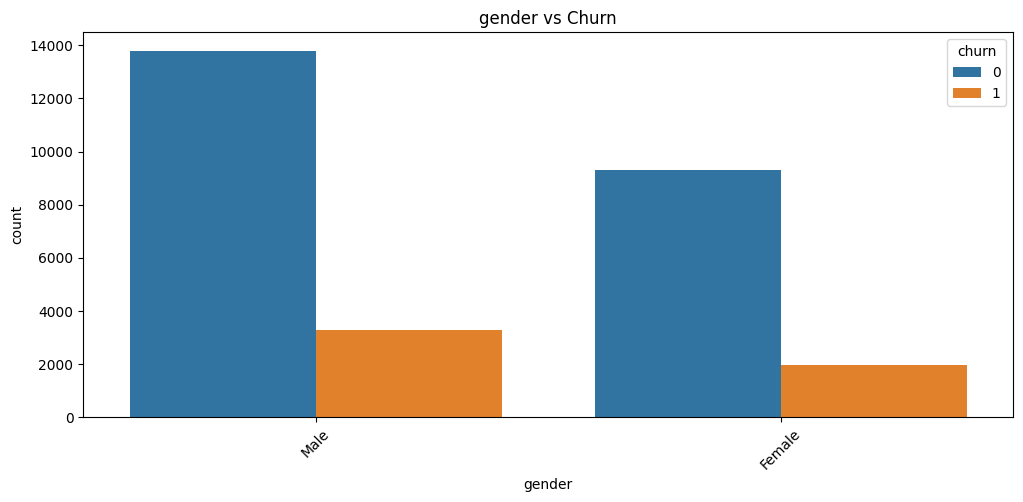

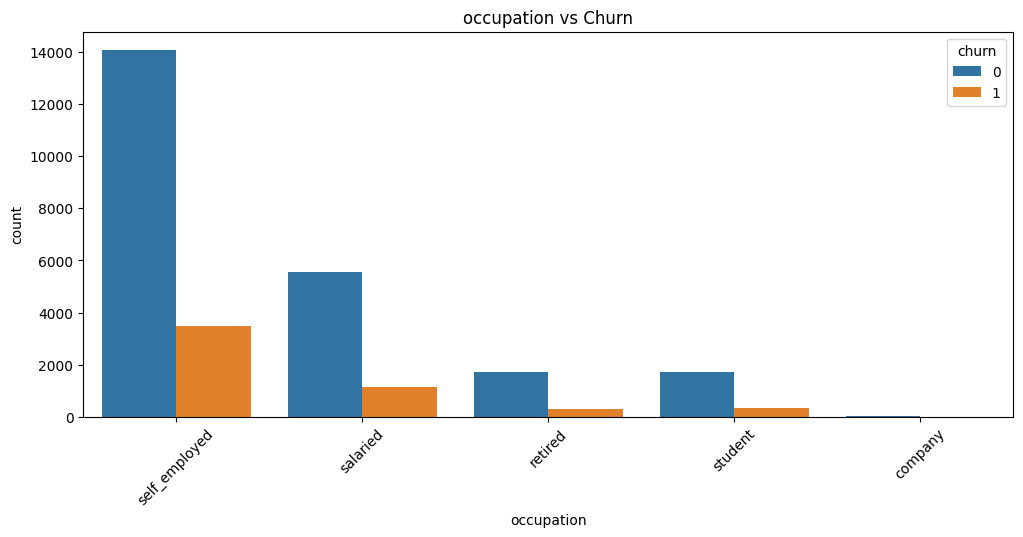

In [ ]:
categorical_cols = ['gender', 'occupation',]
for col in categorical_cols:
    plt.figure(figsize=(12,5))
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

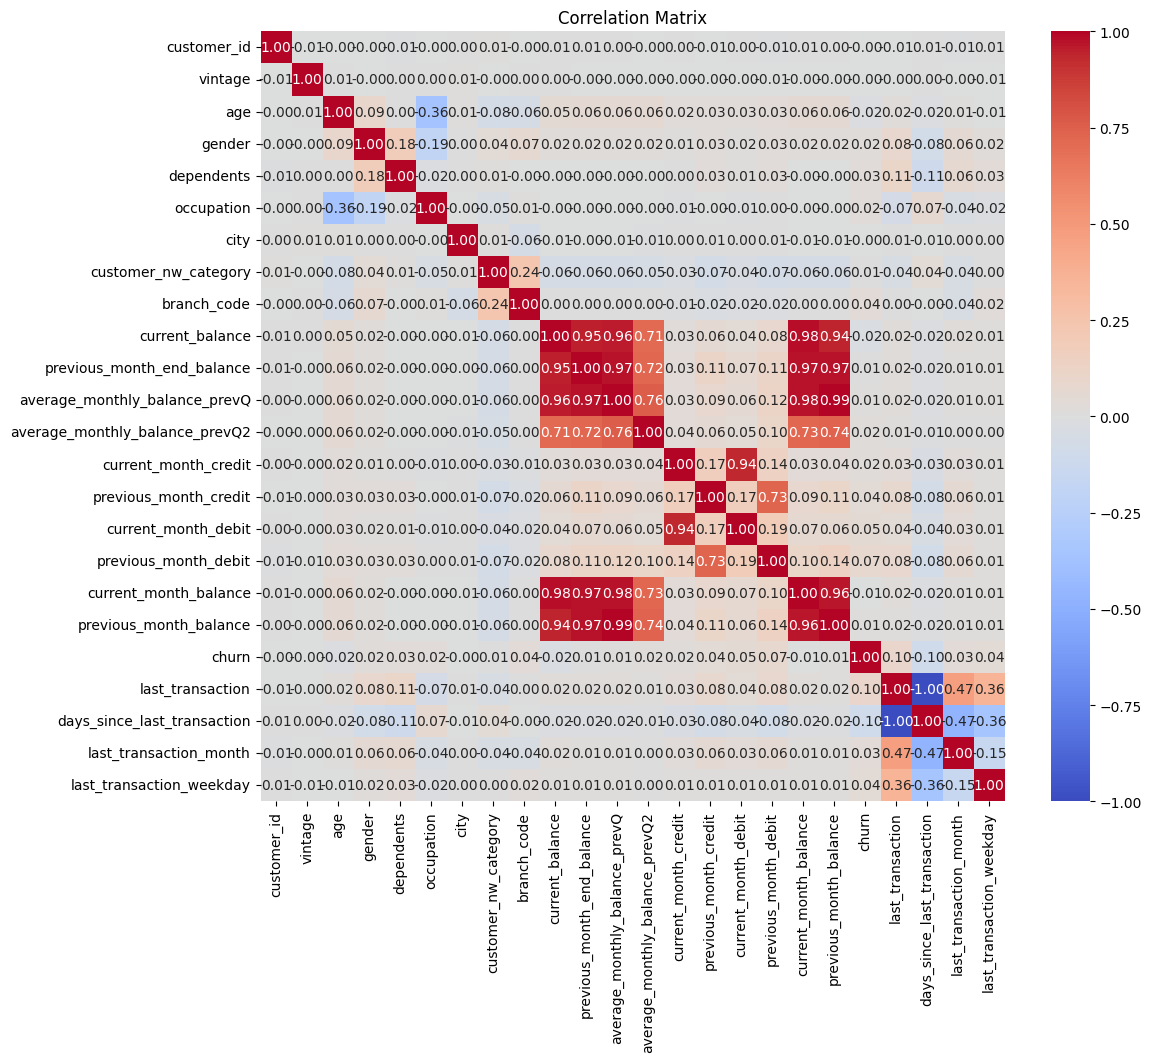

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
top_corr = corr_matrix['churn'].sort_values(ascending=False)
print("Top features correlated with churn:\n", top_corr.head(10))
print("Lowest features correlated with churn:\n", top_corr.tail(10))


Top features correlated with churn:
 churn                       1.000000
last_transaction            0.099664
previous_month_debit        0.073058
current_month_debit         0.048041
previous_month_credit       0.042179
last_transaction_weekday    0.039404
branch_code                 0.035469
last_transaction_month      0.034240
dependents                  0.029335
occupation                  0.023928
Name: churn, dtype: float64
Lowest features correlated with churn:
 average_monthly_balance_prevQ    0.011960
previous_month_end_balance       0.006886
customer_nw_category             0.006551
city                            -0.000883
customer_id                     -0.002723
vintage                         -0.004769
current_month_balance           -0.006391
age                             -0.020012
current_balance                 -0.024181
days_since_last_transaction     -0.099664
Name: churn, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          28382 non-null  object 
 4   dependents                      28382 non-null  float64
 5   occupation                      28382 non-null  object 
 6   city                            28382 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Encode gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])  # Male=1, Female=0 (or vice versa)

# One-Hot Encode occupation
df['occupation'] = le.fit_transform(df['occupation'])

# Optional: Process last_transaction
df['last_transaction'] = pd.to_datetime(df['last_transaction'])
current_date = pd.to_datetime('2019-12-31')  # or the max date in dataset
df['days_since_last_transaction'] = (current_date - df['last_transaction']).dt.days
df['last_transaction_month'] = df['last_transaction'].dt.month
df['last_transaction_weekday'] = df['last_transaction'].dt.weekday


/tmp/ipython-input-1302946825.py:12: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_transaction'] = pd.to_datetime(df['last_transaction'])


In [ ]:
df

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,days_since_last_transaction,last_transaction_month,last_transaction_weekday
0,1,2101,66,1,0.0,3,187.0,2,755,1458.71,...,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,224,5,1
1,2,2348,35,1,0.0,3,1020.0,2,3214,5390.37,...,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,60,11,4
2,4,2194,31,1,0.0,2,146.0,2,41,3913.16,...,0.61,6046.73,259.23,5006.28,5070.14,0,2018-12-31,365,12,0
3,5,2329,90,1,0.0,3,1020.0,2,582,2291.91,...,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,147,8,1
4,6,1579,42,1,2.0,3,1494.0,3,388,927.72,...,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,58,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,30297,2325,10,0,0.0,4,1020.0,2,1207,1076.43,...,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22,70,10,1
28378,30298,1537,34,0,0.0,3,1046.0,2,223,3844.10,...,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17,14,12,1
28379,30299,2376,47,1,0.0,2,1096.0,2,588,65511.97,...,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31,0,12,1
28380,30300,1745,50,1,3.0,3,1219.0,3,274,1625.55,...,0.20,0.20,0.20,1625.55,1625.55,0,2018-12-31,365,12,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   customer_id                     28382 non-null  int64         
 1   vintage                         28382 non-null  int64         
 2   age                             28382 non-null  int64         
 3   gender                          28382 non-null  int64         
 4   dependents                      28382 non-null  float64       
 5   occupation                      28382 non-null  int64         
 6   city                            28382 non-null  float64       
 7   customer_nw_category            28382 non-null  int64         
 8   branch_code                     28382 non-null  int64         
 9   current_balance                 28382 non-null  float64       
 10  previous_month_end_balance      28382 non-null  float64       
 11  av

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [ ]:
X = df.drop('churn', axis=1)
X = X.drop('last_transaction', axis=1)
y = df['churn']

In [ ]:
X.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance',
       'days_since_last_transaction', 'last_transaction_month',
       'last_transaction_weekday'],
      dtype='object')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.8197991897128765


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[4597   28]
 [ 995   57]]


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90      4625
           1       0.67      0.05      0.10      1052

    accuracy                           0.82      5677
   macro avg       0.75      0.52      0.50      5677
weighted avg       0.79      0.82      0.75      5677



In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7595969581749049
